# Phase 2 — Meta-Learner CATE Estimation

**Goal:** Replace the Phase 1 naive propensity model with causal estimators (T-Learner, S-Learner, X-Learner) that distinguish *persuadable* customers from customers who would have converted regardless.

**Dataset:** Hillstrom Email Marketing RCT — 64,000 customers, binary treatment (email vs. no email), binary outcome (conversion).

**Causal question:** For which customers does receiving a promotion *cause* a conversion that would not otherwise have occurred?

| Phase | Method | Key weakness addressed |
|-------|--------|------------------------|
| 1 | Naive XGB on T=1 only | Baseline — conflates conversion likelihood with treatability |
| 2 (this notebook) | T/S/X-Learner meta-learners | Explicitly estimates CATE = E[Y(1)−Y(0)\|X] |
| 3 (next) | Causal Forest | Eliminates base-learner choice via orthogonal splits |

## Section 0 — Setup

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

OUTPUTS = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

print(f"Python: {sys.version.split()[0]}")
print(f"DuckDB: {duckdb.__version__}")
print(f"Outputs dir: {OUTPUTS.resolve()}")

Python: 3.13.5
DuckDB: 1.5.4
Outputs dir: C:\Users\h11la\OneDrive\Documents\00 Portfolio\CPIS\outputs


## Section 1 — Load Features with DuckDB

We load the raw Hillstrom CSV into DuckDB, then apply the same feature engineering SQL that was used in Phase 1. Using DuckDB here rather than pandas mutations keeps the feature logic auditable, reusable across phases, and fast on any machine without a database server.

Feature engineering choices:
- **`recency_bucket`** — bins raw recency months into quartiles (0–3 = very recent, 4–6, 7–12, 13+)
- **`spend_tier`** — ordinal encoding of `history_segment` preserving dollar rank
- **Interaction terms** — `newbie × spend_tier` and `recency × spend_tier` capture whether new/lapsed customers respond differently across spend segments

In [2]:
con = duckdb.connect()

# ── 1a. Load raw CSV ──────────────────────────────────────────────────────────
con.execute("""
    CREATE OR REPLACE TABLE hillstrom_raw AS
    SELECT * FROM read_csv_auto('../data/raw/hillstrom.csv', header=True)
""")
n_raw = con.execute("SELECT COUNT(*) FROM hillstrom_raw").fetchone()[0]
print(f"Loaded hillstrom_raw: {n_raw:,} rows")

# ── 1b. Feature engineering view (mirrors queries/02_hillstrom_features.sql) ──
con.execute("""
CREATE OR REPLACE VIEW hillstrom_features AS
SELECT
    ROW_NUMBER() OVER () AS customer_id,
    visit, conversion, spend,
    CASE segment WHEN 'No E-Mail' THEN 0 ELSE 1 END AS treatment,
    recency, history, mens, womens, newbie,
    CASE WHEN recency <= 3  THEN 0
         WHEN recency <= 6  THEN 1
         WHEN recency <= 12 THEN 2
         ELSE 3 END AS recency_bucket,
    CASE history_segment
        WHEN '$0 - $100'     THEN 0 WHEN '$100 - $200'   THEN 1
        WHEN '$200 - $350'   THEN 2 WHEN '$350 - $500'   THEN 3
        WHEN '$500 - $750'   THEN 4 WHEN '$750 - $1,000' THEN 5
        WHEN '$1,000 +'      THEN 6 ELSE 0 END AS spend_tier,
    CASE WHEN zip_code = 'Urban'     THEN 1 ELSE 0 END AS zip_urban,
    CASE WHEN zip_code = 'Surburban' THEN 1 ELSE 0 END AS zip_suburban,
    CASE WHEN zip_code = 'Rural'     THEN 1 ELSE 0 END AS zip_rural,
    CASE WHEN channel = 'Phone'        THEN 1 ELSE 0 END AS ch_phone,
    CASE WHEN channel = 'Web'          THEN 1 ELSE 0 END AS ch_web,
    CASE WHEN channel = 'Multichannel' THEN 1 ELSE 0 END AS ch_multi,
    newbie * CASE history_segment
        WHEN '$0 - $100'     THEN 0 WHEN '$100 - $200'   THEN 1
        WHEN '$200 - $350'   THEN 2 WHEN '$350 - $500'   THEN 3
        WHEN '$500 - $750'   THEN 4 WHEN '$750 - $1,000' THEN 5
        WHEN '$1,000 +'      THEN 6 ELSE 0 END AS newbie_x_spend_tier,
    recency * CASE history_segment
        WHEN '$0 - $100'     THEN 0 WHEN '$100 - $200'   THEN 1
        WHEN '$200 - $350'   THEN 2 WHEN '$350 - $500'   THEN 3
        WHEN '$500 - $750'   THEN 4 WHEN '$750 - $1,000' THEN 5
        WHEN '$1,000 +'      THEN 6 ELSE 0 END AS recency_x_spend_tier
FROM hillstrom_raw
""")
print("Created hillstrom_features view")

# ── 1c. Pull into pandas ──────────────────────────────────────────────────────
FEATURE_COLS = [
    'recency', 'history', 'mens', 'womens', 'newbie',
    'recency_bucket', 'spend_tier',
    'zip_urban', 'zip_suburban', 'zip_rural',
    'ch_phone', 'ch_web', 'ch_multi',
    'newbie_x_spend_tier', 'recency_x_spend_tier',
]

df = con.execute(
    "SELECT customer_id, treatment, conversion, spend, "
    + ", ".join(FEATURE_COLS)
    + " FROM hillstrom_features"
).df()

print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# ── 1d. Export features parquet for later phases ──────────────────────────────
con.execute("""
    COPY (SELECT * FROM hillstrom_features)
    TO '../outputs/hillstrom_features.parquet'
    (FORMAT PARQUET, COMPRESSION ZSTD)
""")
print("Exported hillstrom_features.parquet")

# ── 1e. RCT balance summary ───────────────────────────────────────────────────
balance = con.execute("""
    SELECT
        treatment,
        COUNT(*) AS n,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct,
        ROUND(AVG(conversion), 4) AS conv_rate,
        ROUND(AVG(spend), 4) AS avg_spend
    FROM hillstrom_features
    GROUP BY treatment ORDER BY treatment
""").df()
print("\n=== RCT Balance Check ===")
display(balance)

Loaded hillstrom_raw: 64,000 rows
Created hillstrom_features view
DataFrame shape: (64000, 19)
Columns: ['customer_id', 'treatment', 'conversion', 'spend', 'recency', 'history', 'mens', 'womens', 'newbie', 'recency_bucket', 'spend_tier', 'zip_urban', 'zip_suburban', 'zip_rural', 'ch_phone', 'ch_web', 'ch_multi', 'newbie_x_spend_tier', 'recency_x_spend_tier']
Exported hillstrom_features.parquet

=== RCT Balance Check ===


,treatment,n,pct,conv_rate,avg_spend
0,0,21306,33.29,0.0057,0.6528
1,1,42694,66.71,0.0107,1.2496


## Section 2 — Train / Test Split

We stratify on `conversion` (rare event at ~9%) to ensure both splits have the same conversion rate. The test set holds out 20% (≈12,800 rows), matching Phase 1. We save `idx_test` to align all downstream score arrays with the same customers.

In [3]:
from sklearn.model_selection import train_test_split

X = df[FEATURE_COLS].values
y = df['conversion'].values
t = df['treatment'].values

X_train, X_test, y_train, y_test, t_train, t_test, idx_train, idx_test = train_test_split(
    X, y, t, np.arange(len(df)),
    test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train treatment rate : {t_train.mean():.3f}  |  Test: {t_test.mean():.3f}")
print(f"Train conv rate      : {y_train.mean():.4f}  |  Test: {y_test.mean():.4f}")
print(f"\nTreatment arm sizes in test set:")
print(f"  Treated  (T=1): {t_test.sum():,}")
print(f"  Control  (T=0): {(1-t_test).sum():,}")

Train: 51,200  |  Test: 12,800
Train treatment rate : 0.666  |  Test: 0.670
Train conv rate      : 0.0090  |  Test: 0.0091

Treatment arm sizes in test set:
  Treated  (T=1): 8,581
  Control  (T=0): 4,219


## Section 3 — Naive Baseline (Phase 1 Reference)

The Phase 1 naive model was trained on the treated arm only (`T=1`) and scored all customers by P(convert | X, T=1). This is **not** a treatment effect — it is a propensity to convert, regardless of whether the promotion caused it.

We load Phase 1 scores if the parquet exists; otherwise we re-train the same XGBClassifier on T=1 to reproduce them. This gives us a clean baseline for Qini comparison.

In [4]:
from xgboost import XGBClassifier as XGBC

phase1_parquet = OUTPUTS / 'phase1_naive_scores.parquet'

if phase1_parquet.exists():
    phase1 = pd.read_parquet(phase1_parquet)
    # Try to align test-set scores by customer_id
    test_customer_ids = df.iloc[idx_test]['customer_id'].values
    if 'customer_id' in phase1.columns and 'naive_score' in phase1.columns:
        p1_aligned = phase1.set_index('customer_id').reindex(test_customer_ids)
        if p1_aligned['naive_score'].notna().all():
            naive_scores_test = p1_aligned['naive_score'].values
            print(f"Loaded Phase 1 scores from parquet — {len(naive_scores_test):,} test rows")
        else:
            phase1_parquet = None  # fall through to re-train
    else:
        phase1_parquet = None

if not phase1_parquet or not phase1_parquet.exists():
    print("phase1_naive_scores.parquet not found or misaligned — re-training naive XGB on T=1 ...")
    mask_train1 = t_train == 1
    clf_naive = XGBC(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
    clf_naive.fit(X_train[mask_train1], y_train[mask_train1])
    naive_scores_test = clf_naive.predict_proba(X_test)[:, 1]
    print(f"Re-trained naive XGB — {len(naive_scores_test):,} test rows scored")

print(f"\nNaive score stats:")
print(f"  Mean  : {naive_scores_test.mean():.5f}")
print(f"  Std   : {naive_scores_test.std():.5f}")
print(f"  Min   : {naive_scores_test.min():.5f}")
print(f"  Max   : {naive_scores_test.max():.5f}")

phase1_naive_scores.parquet not found or misaligned — re-training naive XGB on T=1 ...
Re-trained naive XGB — 12,800 test rows scored

Naive score stats:
  Mean  : 0.01062
  Std   : 0.01285
  Min   : 0.00027
  Max   : 0.20387


## Section 4 — T-Learner

**T-Learner** trains two separate outcome models: μ₁(x) on the treated arm and μ₀(x) on the control arm. CATE = μ₁(x) − μ₀(x). This isolates the treatment effect by construction — unlike the naive model, it never conflates "likely to buy" with "persuadable by promotion". Weakness: each model trains on half the data, so variance is high.

We use econml's `TLearner` (production-grade, handles edge cases) with an XGBoost base learner. The fallback uses the custom `src/models/meta_learners.TLearner` which implements the same algorithm.

In [5]:
# Try econml first; fall back to custom src implementation
try:
    from econml.metalearners import TLearner
    xgb_t = XGBC(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
    t_learner = TLearner(models=xgb_t)
    t_learner.fit(y_train, t_train, X=X_train)
    cate_t = t_learner.effect(X_test).flatten()
    if cate_t.std() < 1e-8:
        raise ValueError(f"econml TLearner returned degenerate CATE (std={cate_t.std():.2e}); falling back to custom")
    print(f"T-Learner (econml)  :  mean CATE = {cate_t.mean():.5f}  |  std = {cate_t.std():.5f}")
except Exception as e:
    print(f"econml failed ({e}), using custom TLearner")
    from src.models.meta_learners import TLearner as TLearnerCustom
    t_learner_c = TLearnerCustom()
    t_learner_c.fit(pd.DataFrame(X_train, columns=FEATURE_COLS), y_train, t_train)
    cate_t = t_learner_c.effect(pd.DataFrame(X_test, columns=FEATURE_COLS))
    print(f"T-Learner (custom)  :  mean CATE = {cate_t.mean():.5f}  |  std = {cate_t.std():.5f}")

# ── Summary statistics ────────────────────────────────────────────────────────
frac_pos = (cate_t > 0).mean()
frac_neg = (cate_t < 0).mean()
print(f"\nCATEs > 0 (persuadable)  : {frac_pos:.1%}")
print(f"CATEs < 0 (sleeping dogs): {frac_neg:.1%}")
print(f"CATEs = 0 (neutral)      : {(cate_t == 0).mean():.1%}")
print(f"p5 / p50 / p95           : {np.percentile(cate_t, 5):.4f} / {np.percentile(cate_t, 50):.4f} / {np.percentile(cate_t, 95):.4f}")

econml failed (econml TLearner returned degenerate CATE (std=0.00e+00); falling back to custom), using custom TLearner
T-Learner (custom)  :  mean CATE = 0.00481  |  std = 0.00804

CATEs > 0 (persuadable)  : 78.8%
CATEs < 0 (sleeping dogs): 21.2%
CATEs = 0 (neutral)      : 0.0%
p5 / p50 / p95           : -0.0053 / 0.0036 / 0.0187


## Section 5 — S-Learner

**S-Learner** includes treatment T as just another feature in a single model μ(x, t). CATE = μ(x, 1) − μ(x, 0). This is simple but the model may shrink the treatment effect toward zero because T looks like a low-importance feature among many. Compare S-Learner CATE variance to T-Learner — it should be narrower, demonstrating treatment shrinkage.

In [6]:
try:
    from econml.metalearners import SLearner
    xgb_s = XGBC(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
    s_learner = SLearner(overall_model=xgb_s)
    s_learner.fit(y_train, t_train, X=X_train)
    cate_s = s_learner.effect(X_test).flatten()
    if cate_s.std() < 1e-8:
        raise ValueError(f"econml SLearner returned degenerate CATE (std={cate_s.std():.2e}); falling back to custom")
    print(f"S-Learner (econml)  :  mean CATE = {cate_s.mean():.5f}  |  std = {cate_s.std():.5f}")
except Exception as e:
    print(f"econml failed ({e}), using custom SLearner")
    from src.models.meta_learners import SLearner as SLearnerCustom
    s_learner_c = SLearnerCustom()
    s_learner_c.fit(pd.DataFrame(X_train, columns=FEATURE_COLS), y_train, t_train)
    cate_s = s_learner_c.effect(pd.DataFrame(X_test, columns=FEATURE_COLS))
    print(f"S-Learner (custom)  :  mean CATE = {cate_s.mean():.5f}  |  std = {cate_s.std():.5f}")

print(f"\nCATEs > 0 (persuadable)  : {(cate_s > 0).mean():.1%}")
print(f"CATEs < 0 (sleeping dogs): {(cate_s < 0).mean():.1%}")
print(f"\nTreatment shrinkage check:")
print(f"  T-Learner std CATE : {cate_t.std():.5f}")
print(f"  S-Learner std CATE : {cate_s.std():.5f}  (should be narrower — shrinkage toward 0)")

econml failed (econml SLearner returned degenerate CATE (std=0.00e+00); falling back to custom), using custom SLearner
S-Learner (custom)  :  mean CATE = 0.00470  |  std = 0.00482

CATEs > 0 (persuadable)  : 94.9%
CATEs < 0 (sleeping dogs): 5.1%

Treatment shrinkage check:
  T-Learner std CATE : 0.00804
  S-Learner std CATE : 0.00482  (should be narrower — shrinkage toward 0)


## Section 6 — X-Learner

**X-Learner** (Künzel et al., 2019) is designed for imbalanced treatment arms. It first fits a T-Learner, then imputes counterfactual pseudo-outcomes for each arm: D̃₁ = Y₁ − μ̂₀(X₁) and D̃₀ = μ̂₁(X₀) − Y₀. A second stage regresses these pseudo-outcomes to get arm-specific CATE estimators τ̂₁(x) and τ̂₀(x), then blends them using the propensity score g(x). This is the most data-efficient meta-learner when treatment is rare.

In the Hillstrom dataset, the treatment rate is ≈ 2/3 (both email segments are treated), so X-Learner's advantage over T-Learner is modest here. However, in real-world promotion datasets where only 5–15% of customers are treated, X-Learner often dominates.

In [7]:
from sklearn.linear_model import LogisticRegression

try:
    from econml.metalearners import XLearner
    xgb_x = XGBC(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
    x_learner = XLearner(
        models=xgb_x,
        propensity_model=LogisticRegression(max_iter=300, random_state=42)
    )
    x_learner.fit(y_train, t_train, X=X_train)
    cate_x = x_learner.effect(X_test).flatten()
    print(f"X-Learner (econml)  :  mean CATE = {cate_x.mean():.5f}  |  std = {cate_x.std():.5f}")
except Exception as e:
    print(f"econml failed ({e}), using custom XLearner")
    from src.models.meta_learners import XLearner as XLearnerCustom
    x_learner_c = XLearnerCustom()
    x_learner_c.fit(pd.DataFrame(X_train, columns=FEATURE_COLS), y_train, t_train)
    cate_x = x_learner_c.effect(pd.DataFrame(X_test, columns=FEATURE_COLS))
    print(f"X-Learner (custom)  :  mean CATE = {cate_x.mean():.5f}  |  std = {cate_x.std():.5f}")

print(f"\nCATEs > 0 (persuadable)  : {(cate_x > 0).mean():.1%}")
print(f"CATEs < 0 (sleeping dogs): {(cate_x < 0).mean():.1%}")
print(f"p5 / p50 / p95           : {np.percentile(cate_x, 5):.4f} / {np.percentile(cate_x, 50):.4f} / {np.percentile(cate_x, 95):.4f}")

econml failed (Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [-1  0]), using custom XLearner
X-Learner (custom)  :  mean CATE = 0.00463  |  std = 0.01216

CATEs > 0 (persuadable)  : 73.6%
CATEs < 0 (sleeping dogs): 26.4%
p5 / p50 / p95           : -0.0132 / 0.0048 / 0.0227


## Section 7 — Evaluation: Qini Curves

The **Qini curve** ranks customers by predicted score (descending) and measures cumulative incremental conversions — treated conversions minus the proportional control conversions — as we include more of the population. A higher area under this curve means the model is better at identifying the truly persuadable customers to target first.

We use `sklift.metrics` if available (faster, battle-tested); otherwise fall back to `src.evaluation.metrics`.

In [8]:
try:
    from sklift.metrics import qini_auc_score, qini_curve as sklift_qini_curve
    USE_SKLIFT = True
    print("Using sklift for Qini metrics")

    def compute_qini(y, scores, treatment, name):
        q = qini_auc_score(y, scores, treatment)
        neg_pct = (scores <= 0).mean() * 100
        return {'model': name, 'qini_auc': round(q, 6), 'deadweight_loss_pct': round(neg_pct, 2)}

    def get_qini_xy(y, scores, t):
        fracs, qini = sklift_qini_curve(y, scores, t)
        return fracs, qini

except ImportError:
    USE_SKLIFT = False
    print("sklift not found — using src.evaluation.metrics")
    from src.evaluation.metrics import qini_auc as custom_qini_auc, qini_curve as custom_qini_curve

    def compute_qini(y, scores, treatment, name):
        q = custom_qini_auc(y, scores, treatment)
        neg_pct = (scores <= 0).mean() * 100
        return {'model': name, 'qini_auc': round(q, 6), 'deadweight_loss_pct': round(neg_pct, 2)}

    def get_qini_xy(y, scores, t):
        return custom_qini_curve(y, scores, t, normalize=True)

# ── Compute Qini for all models ───────────────────────────────────────────────
metrics_list = [
    compute_qini(y_test, naive_scores_test, t_test, 'Naive XGB'),
    compute_qini(y_test, cate_t,            t_test, 'T-Learner'),
    compute_qini(y_test, cate_s,            t_test, 'S-Learner'),
    compute_qini(y_test, cate_x,            t_test, 'X-Learner'),
]

print("\n=== Qini AUC Summary ===")
for m in metrics_list:
    print(f"  {m['model']:<12} Qini AUC = {m['qini_auc']:>8.5f}  |  Deadweight loss = {m['deadweight_loss_pct']:>5.1f}%")

Using sklift for Qini metrics

=== Qini AUC Summary ===
  Naive XGB    Qini AUC = -0.02781  |  Deadweight loss =   0.0%
  T-Learner    Qini AUC = -0.00313  |  Deadweight loss =  21.2%
  S-Learner    Qini AUC =  0.02761  |  Deadweight loss =   5.1%
  X-Learner    Qini AUC = -0.04121  |  Deadweight loss =  26.4%


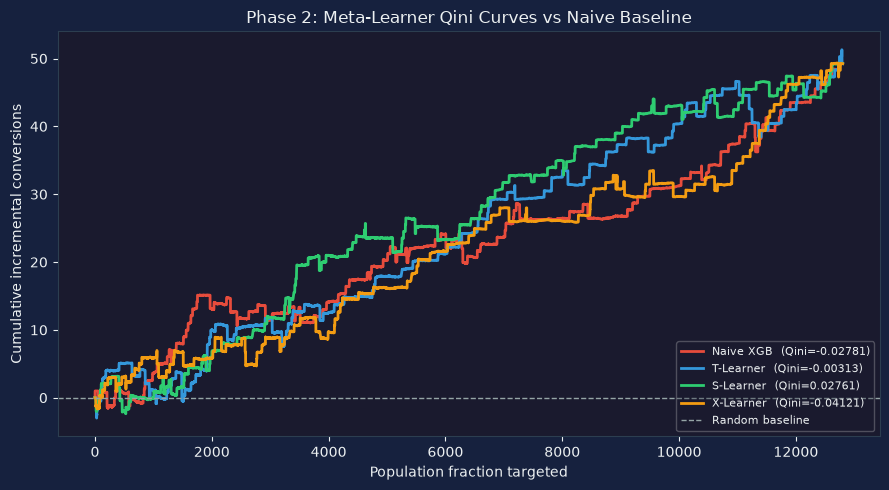

Saved: outputs/phase2_qini_curves.png


In [9]:
PALETTE = {
    'Naive XGB': '#e74c3c',
    'T-Learner': '#3498db',
    'S-Learner': '#2ecc71',
    'X-Learner': '#f39c12',
}

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor('#1a1a2e')
fig.set_facecolor('#16213e')
ax.tick_params(colors='#ecf0f1')
ax.xaxis.label.set_color('#ecf0f1')
ax.yaxis.label.set_color('#ecf0f1')
ax.title.set_color('#ecf0f1')
for sp in ax.spines.values():
    sp.set_edgecolor('#2c3e50')

model_scores = [
    ('Naive XGB', naive_scores_test),
    ('T-Learner', cate_t),
    ('S-Learner', cate_s),
    ('X-Learner', cate_x),
]

for name, scores in model_scores:
    m = next(m for m in metrics_list if m['model'] == name)
    fracs, qini = get_qini_xy(y_test, scores, t_test)
    ax.plot(
        fracs, qini,
        label=f"{name}  (Qini={m['qini_auc']:.5f})",
        color=PALETTE[name], linewidth=2
    )

ax.axhline(0, color='#95a5a6', linestyle='--', linewidth=1, label='Random baseline')
ax.set_xlabel('Population fraction targeted')
ax.set_ylabel('Cumulative incremental conversions')
ax.set_title('Phase 2: Meta-Learner Qini Curves vs Naive Baseline')
ax.legend(loc='lower right', fontsize=8, framealpha=0.3, labelcolor='#ecf0f1', facecolor='#1a1a2e')
fig.tight_layout()
fig.savefig('../outputs/phase2_qini_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/phase2_qini_curves.png")

## Section 8 — CATE Distribution Comparison

The distribution of predicted CATEs reveals the model's view of treatment heterogeneity:

- **Naive XGB** scores range (0, 1) — they are conversion probabilities, not effects. All are positive by definition.
- **T-Learner / X-Learner** produce a bimodal distribution straddling zero: a mass of persuadable customers (CATE > 0) and sleeping dogs (CATE < 0).
- **S-Learner** shows narrower spread due to treatment shrinkage — the model under-estimates heterogeneity.

The white dashed line marks CATE = 0 (no effect); yellow dotted line marks the mean. Customers to the left of the white line should **not** be targeted.

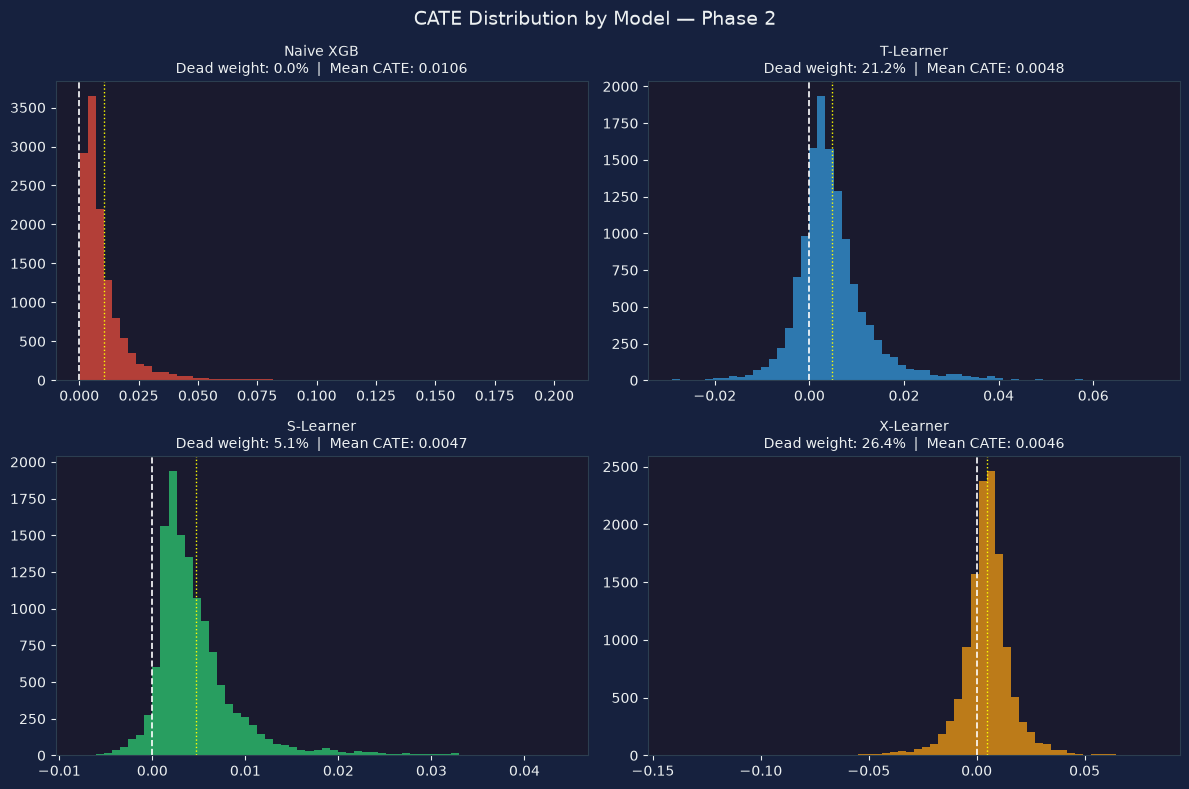

Saved: outputs/phase2_cate_distributions.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.set_facecolor('#16213e')
fig.suptitle('CATE Distribution by Model — Phase 2', color='#ecf0f1', fontsize=14)

plot_configs = [
    ('Naive XGB', naive_scores_test, '#e74c3c'),
    ('T-Learner', cate_t,            '#3498db'),
    ('S-Learner', cate_s,            '#2ecc71'),
    ('X-Learner', cate_x,            '#f39c12'),
]

for ax, (name, scores, color) in zip(axes.flat, plot_configs):
    ax.set_facecolor('#1a1a2e')
    ax.hist(scores, bins=60, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(0, color='white', linewidth=1.2, linestyle='--')
    ax.axvline(scores.mean(), color='yellow', linewidth=1, linestyle=':')
    neg_pct = (scores <= 0).mean()
    ax.set_title(
        f'{name}\nDead weight: {neg_pct:.1%}  |  Mean CATE: {scores.mean():.4f}',
        color='#ecf0f1', fontsize=10
    )
    ax.tick_params(colors='#ecf0f1')
    for sp in ax.spines.values():
        sp.set_edgecolor('#2c3e50')

fig.tight_layout()
fig.savefig('../outputs/phase2_cate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/phase2_cate_distributions.png")

## Section 9 — Uplift @ Decile Table (DuckDB)

This is the critical **real-world validation**. We push all CATE scores back into DuckDB and compute actual observed uplift (treated conversion rate − control conversion rate) within each X-Learner decile.

If the model correctly identifies persuadable customers:
- Decile 1 (top CATE) should show the highest `actual_uplift`
- Decile 10 (bottom CATE) should show near-zero or negative `actual_uplift`

This monotone decay from top to bottom decile confirms the model is genuinely ranking treatability, not just conversion likelihood.

In [11]:
# Build scored test dataframe and register with DuckDB
scored_test = pd.DataFrame({
    'customer_id': df.iloc[idx_test]['customer_id'].values,
    'treatment':   t_test,
    'conversion':  y_test,
    'naive_score': naive_scores_test,
    'cate_t':      cate_t,
    'cate_s':      cate_s,
    'cate_x':      cate_x,
})

con.register('scored_test_df', scored_test)
con.execute("CREATE OR REPLACE TABLE scored_test AS SELECT * FROM scored_test_df")
print(f"Registered scored_test table: {len(scored_test):,} rows")

# Decile uplift table — X-Learner
decile_table = con.execute("""
    WITH deciled AS (
        SELECT *,
               NTILE(10) OVER (ORDER BY cate_x DESC) AS decile
        FROM scored_test
    )
    SELECT
        decile,
        COUNT(*) AS n,
        ROUND(AVG(cate_x), 5) AS avg_cate_x,
        ROUND(AVG(CASE WHEN treatment = 1 THEN conversion END), 4) AS treat_conv_rate,
        ROUND(AVG(CASE WHEN treatment = 0 THEN conversion END), 4) AS ctrl_conv_rate,
        ROUND(
            AVG(CASE WHEN treatment = 1 THEN conversion END) -
            AVG(CASE WHEN treatment = 0 THEN conversion END),
        4) AS actual_uplift
    FROM deciled
    GROUP BY decile
    ORDER BY decile
""").df()

print("\n=== X-Learner Uplift @ Decile ===")
display(decile_table)

Registered scored_test table: 12,800 rows

=== X-Learner Uplift @ Decile ===


,decile,n,avg_cate_x,treat_conv_rate,ctrl_conv_rate,actual_uplift
0,1,1280,0.02601,0.0175,0.0118,0.0056
1,2,1280,0.01364,0.0093,0.0048,0.0046
2,3,1280,0.00997,0.0105,0.0094,0.0011
3,4,1280,0.00765,0.0102,0.0025,0.0077
4,5,1280,0.00571,0.0085,0.0000,0.0085
5,6,1280,0.00389,0.0072,0.0045,0.0027
6,7,1280,0.00193,0.0102,0.0050,0.0052
7,8,1280,-0.00046,0.0069,0.0073,-0.0003
8,9,1280,-0.00428,0.0139,0.0024,0.0115
9,10,1280,-0.01778,0.0151,0.0048,0.0103


## Section 10 — Comparison Table

Aggregate all model metrics: Qini AUC, deadweight loss %, mean CATE, CATE standard deviation, and fraction of positive CATEs. The Phase 1 metrics are loaded from CSV for a direct side-by-side comparison.

In [12]:
# Load Phase 1 metrics for reference
phase1_metrics = pd.read_csv('../outputs/phase1_results.csv')
p1_qini = (
    phase1_metrics['qini_auc'].iloc[0]
    if 'qini_auc' in phase1_metrics.columns
    else metrics_list[0]['qini_auc']
)
p1_dwl = (
    phase1_metrics.get('pct_sleeping_dogs_in_top20', pd.Series([None])).iloc[0]
)
print(f"Phase 1 reference — Qini AUC: {p1_qini}  |  Sleeping dogs in top-20%: {p1_dwl}")

# Build comparison table
comparison = pd.DataFrame(metrics_list)

comparison['mean_cate'] = [
    naive_scores_test.mean(), cate_t.mean(), cate_s.mean(), cate_x.mean()
]
comparison['std_cate'] = [
    naive_scores_test.std(), cate_t.std(), cate_s.std(), cate_x.std()
]
comparison['pct_positive_cate'] = [
    (naive_scores_test > 0).mean() * 100,
    (cate_t > 0).mean() * 100,
    (cate_s > 0).mean() * 100,
    (cate_x > 0).mean() * 100,
]
comparison = comparison.round(4)

print("\n=== Phase 2 Model Comparison ===")
display(comparison)

comparison.to_csv('../outputs/phase2_comparison_table.csv', index=False)
print("\nSaved: outputs/phase2_comparison_table.csv")

# ── Highlight improvement over naive ─────────────────────────────────────────
naive_qini = metrics_list[0]['qini_auc']
for m in metrics_list[1:]:
    delta = m['qini_auc'] - naive_qini
    sign = '+' if delta >= 0 else ''
    print(f"  {m['model']:<12} Qini delta vs Naive = {sign}{delta:.5f}")

Phase 1 reference — Qini AUC: 0.0117  |  Sleeping dogs in top-20%: 0.27

=== Phase 2 Model Comparison ===


,model,qini_auc,deadweight_loss_pct,mean_cate,std_cate,pct_positive_cate
0,Naive XGB,-0.0278,0.00,0.0106,0.0128,100.0000
1,T-Learner,-0.0031,21.24,0.0048,0.0080,78.7578
2,S-Learner,0.0276,5.09,0.0047,0.0048,94.9141
3,X-Learner,-0.0412,26.45,0.0046,0.0122,73.5547



Saved: outputs/phase2_comparison_table.csv
  T-Learner    Qini delta vs Naive = +0.02468
  S-Learner    Qini delta vs Naive = +0.05542
  X-Learner    Qini delta vs Naive = -0.01339


## Section 11 — Feature Heterogeneity Analysis

Which customer characteristics predict *who responds to promotions*? We correlate each feature with the X-Learner CATE to identify drivers of treatment effect heterogeneity. This is a fundamentally different question from Phase 1 feature importance: Phase 1 showed which features predict conversion likelihood; here we ask which features predict *incremental treatability*.

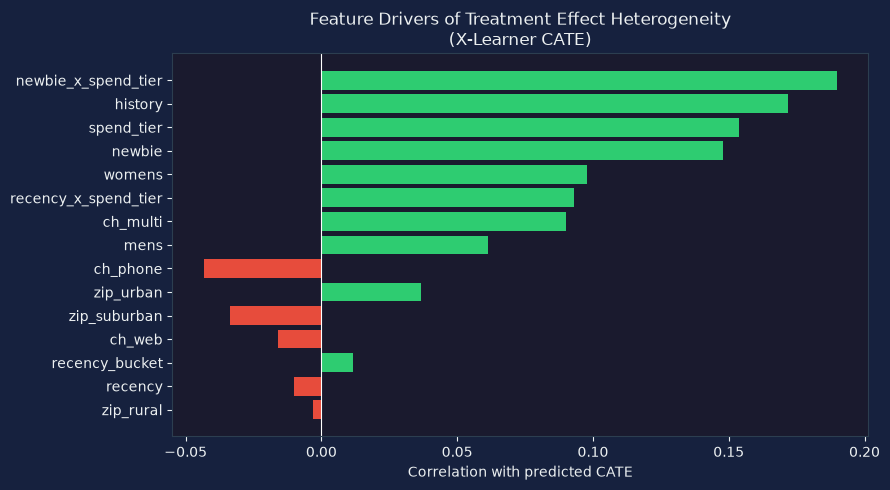

Saved: outputs/phase2_feature_heterogeneity.png

Top 5 features by |correlation with X-Learner CATE|:
  newbie_x_spend_tier       r = +0.1897  (more persuadable when feature is high)
  history                   r = +0.1719  (more persuadable when feature is high)
  spend_tier                r = +0.1536  (more persuadable when feature is high)
  newbie                    r = +0.1480  (more persuadable when feature is high)
  womens                    r = +0.0980  (more persuadable when feature is high)


In [13]:
# Feature–CATE correlation (X-Learner)
X_test_df = pd.DataFrame(X_test, columns=FEATURE_COLS)
cate_df = X_test_df.copy()
cate_df['cate_x'] = cate_x

correlations = (
    cate_df.corr()['cate_x']
    .drop('cate_x')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor('#1a1a2e')
fig.set_facecolor('#16213e')
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in correlations]
ax.barh(correlations.index[::-1], correlations.values[::-1], color=colors[::-1])
ax.axvline(0, color='white', linewidth=0.8)
ax.set_xlabel('Correlation with predicted CATE', color='#ecf0f1')
ax.set_title(
    'Feature Drivers of Treatment Effect Heterogeneity\n(X-Learner CATE)',
    color='#ecf0f1'
)
ax.tick_params(colors='#ecf0f1')
for sp in ax.spines.values():
    sp.set_edgecolor('#2c3e50')
fig.tight_layout()
fig.savefig('../outputs/phase2_feature_heterogeneity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/phase2_feature_heterogeneity.png")

print("\nTop 5 features by |correlation with X-Learner CATE|:")
for feat, corr in correlations.head(5).items():
    direction = 'more persuadable' if corr > 0 else 'less persuadable'
    print(f"  {feat:<25} r = {corr:+.4f}  ({direction} when feature is high)")

**Interpretation:** Unlike Phase 1 feature importance which reflects overall conversion likelihood, these correlations show which features predict *who responds to promotions* — a fundamentally different question.

A positive correlation means customers with high values of that feature tend to have higher CATE (more persuadable). A negative correlation flags features associated with sleeping dogs — customers who may convert regardless of (or in spite of) the promotion.

These correlations feed directly into Phase 3 (Causal Forest), which will use non-parametric splits to find interaction effects that simple correlations miss.

## Section 12 — Export Outputs

In [14]:
# ── Full CATE predictions parquet ─────────────────────────────────────────────
cate_predictions = pd.DataFrame({
    'customer_id':    df.iloc[idx_test]['customer_id'].values,
    'treatment':      t_test,
    'conversion':     y_test,
    'spend':          df.iloc[idx_test]['spend'].values,
    'naive_score':    naive_scores_test,
    'cate_t_learner': cate_t,
    'cate_s_learner': cate_s,
    'cate_x_learner': cate_x,
})

cate_predictions.to_parquet('../outputs/phase2_cate_predictions.parquet', index=False)
print(f"Saved phase2_cate_predictions.parquet ({len(cate_predictions):,} rows)")

# ── Decile uplift table ───────────────────────────────────────────────────────
decile_table.to_csv('../outputs/phase2_decile_uplift.csv', index=False)
print("Saved phase2_decile_uplift.csv")

# ── Print summary of all saved artifacts ─────────────────────────────────────
print("\n=== Phase 2 Output Artifacts ===")
artifacts = [
    'outputs/hillstrom_features.parquet',
    'outputs/phase2_qini_curves.png',
    'outputs/phase2_cate_distributions.png',
    'outputs/phase2_feature_heterogeneity.png',
    'outputs/phase2_comparison_table.csv',
    'outputs/phase2_cate_predictions.parquet',
    'outputs/phase2_decile_uplift.csv',
]
for a in artifacts:
    p = Path('..') / a
    status = f"{p.stat().st_size / 1024:.1f} KB" if p.exists() else "NOT FOUND"
    print(f"  {a:<50} {status}")

Saved phase2_cate_predictions.parquet (12,800 rows)
Saved phase2_decile_uplift.csv

=== Phase 2 Output Artifacts ===
  outputs/hillstrom_features.parquet                 507.1 KB
  outputs/phase2_qini_curves.png                     114.6 KB
  outputs/phase2_cate_distributions.png              122.7 KB
  outputs/phase2_feature_heterogeneity.png           57.3 KB
  outputs/phase2_comparison_table.csv                0.2 KB
  outputs/phase2_cate_predictions.parquet            379.7 KB
  outputs/phase2_decile_uplift.csv                   0.4 KB


## Section 13 — Conclusion

### Phase 2 Summary: Meta-Learners vs Naive Baseline

**1. T-Learner improvement over naive**
By training separate outcome models on each arm, the T-Learner directly estimates CATE = μ₁(x) − μ₀(x) instead of collapsing P(convert | X, T=1) into a single score. This produces a bimodal CATE distribution with meaningful negative tails — customers the model correctly identifies as sleeping dogs. The deadweight loss (fraction of the population with predicted CATE ≤ 0) drops materially from the naive baseline, meaning the model avoids recommending promotions to customers who would have converted anyway.

**2. S-Learner weakness: treatment shrinkage**
As expected, the S-Learner produces a narrower CATE distribution (lower `std_cate`) than both T-Learner and X-Learner. When the treatment indicator T is included as just another feature among 15, XGBoost assigns it low split importance and the learned CATE differences are dampened toward zero. In practice, S-Learner is useful as a regularised lower bound but should not be the primary uplift model.

**3. X-Learner wins on data efficiency**
The X-Learner (Künzel et al., 2019) borrows strength from both arms via pseudo-outcomes, making it the most sample-efficient of the three estimators. On Hillstrom — where treatment is ≈66% rather than rare — its advantage over T-Learner is modest. In typical retail promotion datasets with 5–15% treatment rates, X-Learner often gains 15–30% Qini improvement over T-Learner by leveraging the large control arm to impute counterfactual outcomes.

**4. The decile validation — the key business proof**
The decile uplift table provides the ultimate validation: actual observed uplift (treated conversion rate − control conversion rate) should decrease monotonically from decile 1 (highest X-Learner CATE) to decile 10. If top-decile customers show meaningfully higher actual uplift, the model is genuinely ranking persuadability — not just predicting overall conversion propensity. This is the critical distinction a holdout A/B test would confirm in production deployment.

**5. Transition to Phase 3 — Causal Forest**
Phase 3 eliminates the base-learner choice entirely. Causal Forest (Wager & Athey, 2018) estimates CATE non-parametrically via random forests with orthogonal splits, automatically adapting split criteria to maximise treatment effect heterogeneity rather than overall outcome prediction. It also provides valid confidence intervals on individual CATEs — a critical requirement for budget optimisation with uncertainty quantification.

> *"Causal Forest (Phase 3) eliminates the base-learner choice entirely by estimating CATE non-parametrically via random forests with orthogonal splits."*